In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from os import walk


In [3]:
figures_folder = "figures"

In [4]:
speed_of_sound = 343.21 # meters per second

In [5]:
folder = "Good Data"
filenames = next(walk(folder), (None, None, []))[2]  # [] if no file]

runs = []

for idx, filename in enumerate(filenames):
    # read the CSV file into a dataframe (i.e. like a Python spreadsheet)
    df = pd.read_csv(folder + "/" + filename)
    
    # convert dataframe into a 2D Numpy array
    a = df.to_numpy()
    
    # the first column are the counters
    counter_array = a[:,0]
    
    # the second column are the time stamps
    # computer_time_stamp_array = a[:,2]
    
    # the second column are the time stamps
    arduino_time_stamp_array = a[:,2]
    # the third column are your measurements: either pulseTime or distance depending on how you modified the code above
    measurement_array = a[:,3]

    if idx == 0: 
        arduino_time_stamp_array = arduino_time_stamp_array[1:]
        measurement_array = measurement_array[1:]
    elif idx == 1: 
        arduino_time_stamp_array = arduino_time_stamp_array[1:]
        measurement_array = measurement_array[1:]
    elif idx == 2: 
        arduino_time_stamp_array = arduino_time_stamp_array[2:]
        measurement_array = measurement_array[2:]
    
    arduino_time_stamp_array -= min(arduino_time_stamp_array)

    arduino_time_stamp_array /= 1000000        

    # there and back, microseconds to seconds, then to meters
    measurement_array = ((measurement_array/2) / 1000000) *  speed_of_sound 

    runs.append((arduino_time_stamp_array, measurement_array))


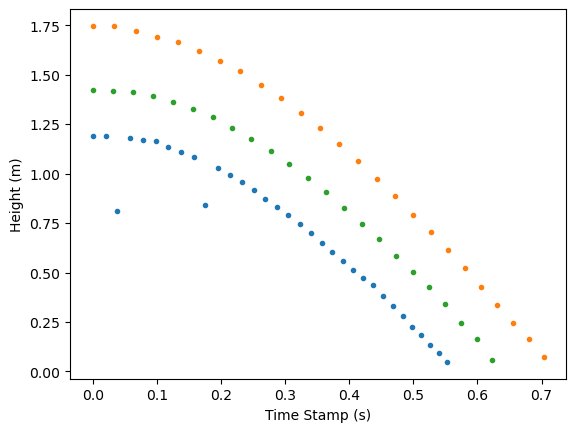

In [6]:
plt.figure()
plt.xlabel("Time Stamp (s)")
plt.ylabel("Height (m)")

for times, heights in runs: 
    plt.plot(times, heights, ".")


In [7]:
length = 22.5 / 100 
length_uncertainty = (0.4 / 100) / 4 # 95% confidence interval 4 mm
width = 10.7 / 100
width_uncertainty = (0.4 / 100) / 4 # 95% confidence interval 4 mm

frontal_area = length * width # m ^ 3

# \delta R = R \sqrt{ \left( \dfrac{\delta X}{X} \right)^2 + \left( \dfrac{\delta Y}{Y} \right)^2 }
frontal_area_uncertainty = frontal_area * np.sqrt(((length_uncertainty / length) ** 2) + ((width_uncertainty / width) ** 2))

print(f"frontal_area is {frontal_area:.4} pm {frontal_area_uncertainty:.4} m^2")

# https://www.engineeringtoolbox.com/air-density-specific-weight-d_600.html
density_of_air = 1.204 # rho in kg m−3

mass = 36.56/1000 # in kg
mass_uncertianty = (0.005 / 1000) / np.sqrt(3)
print(f"Mass is {mass:.4} pm {mass_uncertianty:.4} kg")

g = 9.81    # set the acceleration due to gravity at UBC (m/s^2)


frontal_area is 0.02407 pm 0.0002491 m^2
Mass is 0.03656 pm 2.887e-06 kg


In [8]:
%matplotlib inline
# qt or inline

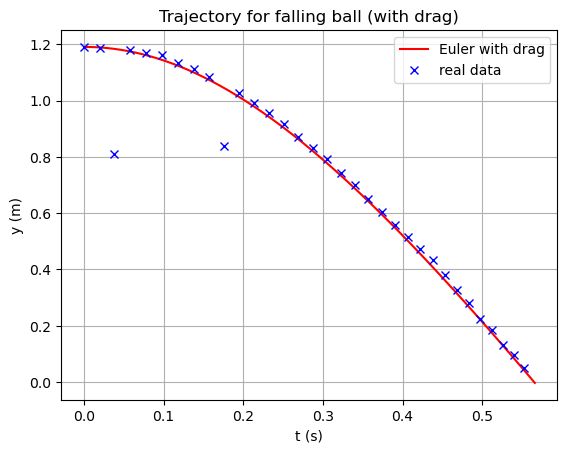

In [9]:
times, heights = runs[0]
    # Define constants
D = 1.81     # drag constant (m^-1) - see last week's worksheet

# Initial conditions as extracted from the video
y = heights[0]              # initial y-position (m) 
vy = 0                  # initial y-velocity (m/s)
t = 0                       # start the simulation at t = 0

# Time step (s)
dt = 0.001    

# initalize some arrays in which we will store position data for later plotting
t_array = []
y_array = []

# Run the Euler simulation in a while loop, you need to add an appropriate condition to stop the loop
# You also need to add all the "physics" inside the loop
while y > 0 :
    ay = -g + ( ( - ((1/2) * D * density_of_air * frontal_area * np.sqrt(vy**2) * vy) ) / mass )           # Calculate acceleration in y-direction

    y = y + vy * dt                    # Update the position in the y direction

    vy = vy + ay * dt                     # Update the velocity in the y direction
 
    t = t + dt               # Increment the time by the time step

    t_array.append(t)     # add x-position to an array for plotting later
    y_array.append(y)   # add y-position to an array for plotting later


# Make the plots
plt.figure()
plt.plot(np.array(t_array), np.array(y_array), "r-", label="Euler with drag")
plt.plot(times, heights, "bx", label="real data")

plt.title("Trajectory for falling ball (with drag)")
plt.xlabel("t (s)")
plt.ylabel("y (m)")
plt.grid(True)
plt.legend()
plt.show()

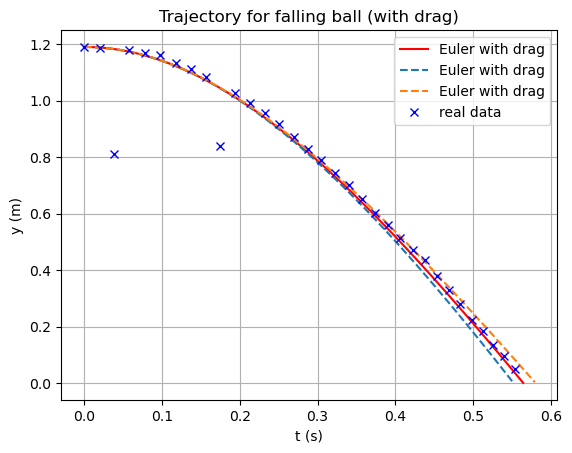

In [10]:
times, heights = runs[0]
    # Define constants
D = np.array([1.5, 1.81, 2.2])         # drag constant (m^-1) - see last week's worksheet

# Initial conditions as extracted from the video
y = np.array([heights[0], heights[0], heights[0]])      # initial y-position (m) 
vy = np.array([0, 0, 0])                  # initial y-velocity (m/s)         
t = 0                       # start the simulation at t = 0

# Time step (s)
dt = 0.001    

# initalize some arrays in which we will store position data for later plotting
t_array = np.array([0])
y_array = np.array([y])

# print(y_array)

# Run the Euler simulation in a while loop, you need to add an appropriate condition to stop the loop
# You also need to add all the "physics" inside the loop
while any(y > 0) :
    ay = -g + ( ( - ((1/2) * D * density_of_air * frontal_area * np.sqrt(vy**2) * vy) ) / mass )           # Calculate acceleration in y-direction

    vy = vy + ay * dt                     # Update the velocity in the y direction
    
    y = y + vy * dt                    # Update the position in the y direction
 
    t = t + dt               # Increment the time by the time step

    t_array = np.append(t_array, t)     # add x-position to an array for plotting later
    y_array = np.vstack([y_array, y])   # add y-position to an array for plotting later
    # print(y_array)


arrays = [y_array[:, 0], y_array[:, 1], y_array[:, 2]]

# Make the plots
plt.figure()
plt.plot(t_array[arrays[1] > 0], arrays[1][arrays[1] > 0], "r-", label="Euler with drag")

plt.plot(t_array[arrays[0] > 0], arrays[0][arrays[0] > 0], "--", label="Euler with drag")
plt.plot(t_array[arrays[2] > 0], arrays[2][arrays[2] > 0], "--", label="Euler with drag")

plt.plot(times, heights, "bx", label="real data")

plt.title("Trajectory for falling ball (with drag)")
plt.xlabel("t (s)")
plt.ylabel("y (m)")
plt.grid(True)
plt.legend()
plt.show()

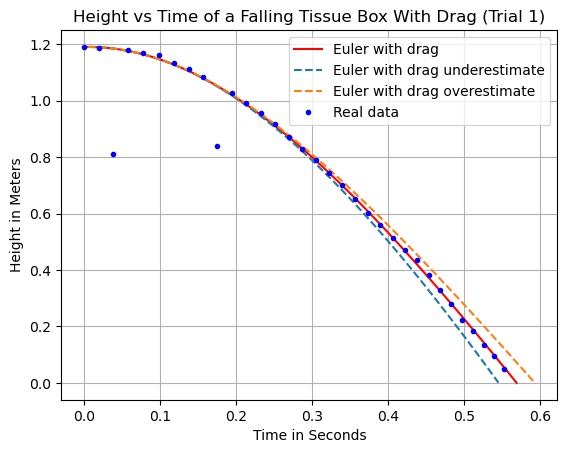

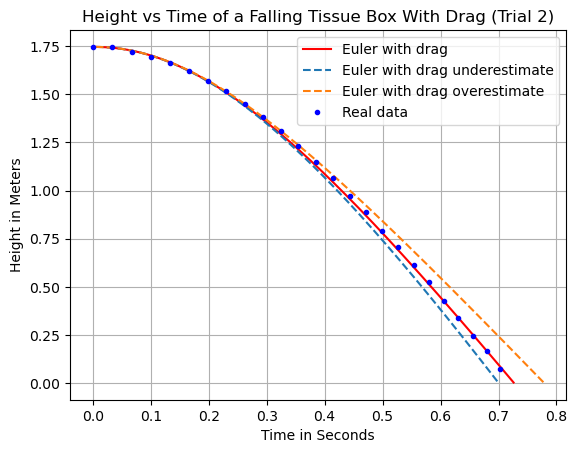

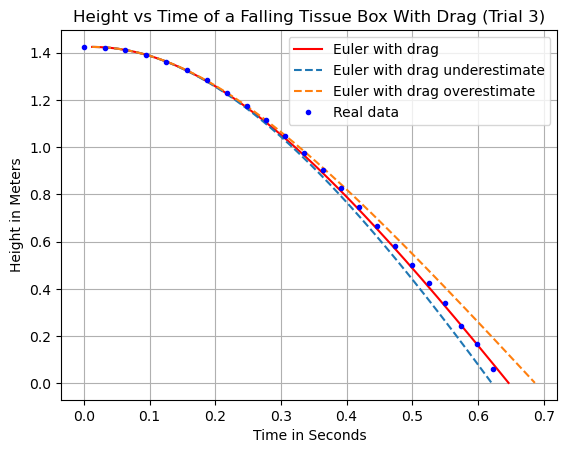

In [11]:

drag_coefficients = [
    np.array([1.22, 1.81, 2.4]),         # drag constant (m^-1) - see last week's worksheet
    np.array([1.4, 1.77, 2.5]),
    np.array([1.35, 1.84, 2.6])
]

time_offsets = [
    0.005, 
    0.005,
    0.0125
]

for idx, ((times, heights), D, time_offset) in enumerate(zip(runs, drag_coefficients, time_offsets)):
        # Define constants
    
    # Initial conditions as extracted from the video
    y = np.array([heights[0], heights[0], heights[0]])      # initial y-position (m) 
    vy = np.array([0, 0, 0])                  # initial y-velocity (m/s)         
    t = time_offset             # start the simulation at t = 0
    
    # Time step (s)
    dt = 0.001    
    
    # initalize some arrays in which we will store position data for later plotting
    t_array = np.array([t])
    y_array = np.array([y])
    
    # print(y_array)
    
    # Run the Euler simulation in a while loop, you need to add an appropriate condition to stop the loop
    # You also need to add all the "physics" inside the loop
    while any(y > 0) :
        ay = -g + ( ( - (1/2) * D * density_of_air * frontal_area * np.sqrt(vy**2) * vy ) / mass )           # Calculate acceleration in y-direction
    
        vy = vy + ay * dt                     # Update the velocity in the y direction
        
        y = y + vy * dt                    # Update the position in the y direction
     
        t = t + dt               # Increment the time by the time step
    
        t_array = np.append(t_array, t)     # add x-position to an array for plotting later
        y_array = np.vstack([y_array, y])   # add y-position to an array for plotting later
        # print(y_array)
    
    
    arrays = [y_array[:, 0], y_array[:, 1], y_array[:, 2]]
    
    # Make the plots
    plt.figure()
    plt.plot(t_array[arrays[1] > 0], arrays[1][arrays[1] > 0], "r-", label="Euler with drag")
    
    plt.plot(t_array[arrays[0] > 0], arrays[0][arrays[0] > 0], "--", label="Euler with drag underestimate")
    plt.plot(t_array[arrays[2] > 0], arrays[2][arrays[2] > 0], "--", label="Euler with drag overestimate")
    
    plt.plot(times, heights, "b.", label="Real data")
    
    plt.title(f"Height vs Time of a Falling Tissue Box With Drag (Trial {idx + 1})")
    plt.xlabel("Time in Seconds")
    plt.ylabel("Height in Meters")
    plt.grid(True)
    plt.legend()
    plt.savefig(figures_folder + f"/EulerFit{idx + 1}.svg", format="svg")
    plt.show()

In [13]:
sigmas = [(drag_coefficient[2] - drag_coefficient[0]) /4 for drag_coefficient in drag_coefficients]
sigmas  

[0.295, 0.275, 0.3125]

In [14]:
for drag_coefficient, sigma in zip(drag_coefficients, sigmas):
    coefficent = drag_coefficient[1]
    print(f"Coefficient of Drag {coefficent:.3} pm {sigma:.3}, relative uncertainty {sigma/coefficent:.3}")

1.81 pm 0.295, relative uncertainty 0.163
1.77 pm 0.275, relative uncertainty 0.155
1.84 pm 0.312, relative uncertainty 0.17


In [39]:
for idx, run in enumerate(runs): 
    print(f"Run {idx} had {len(run[1])} datapoints")

Run 0 had 33 datapoints
Run 1 had 25 datapoints
Run 2 had 23 datapoints


In [16]:
for i in range(0, len(drag_coefficients)): 
    for j in range(i + 1, len(drag_coefficients)):     
        t_prime = np.abs(drag_coefficients[i][1] - drag_coefficients[j][1]) / np.sqrt(sigmas[i]**2 + sigmas[j]**2)
        print(f"t_prime bettween trial {i + 1} and trial {j + 1} is {t_prime:.4}")

t_prime bettween trial 1 and trial 2 is 0.09918
t_prime bettween trial 1 and trial 3 is 0.06981
t_prime bettween trial 2 and trial 3 is 0.1682


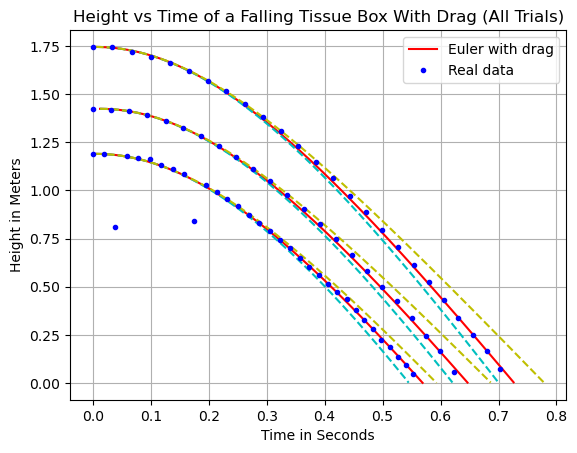

In [18]:
plt.figure()

for idx, ((times, heights), D, time_offset) in enumerate(zip(runs, drag_coefficients, time_offsets)):
        # Define constants
    
    # Initial conditions as extracted from the video
    y = np.array([heights[0], heights[0], heights[0]])      # initial y-position (m) 
    vy = np.array([0, 0, 0])                  # initial y-velocity (m/s)         
    t = time_offset             # start the simulation at t = 0
    
    # Time step (s)
    dt = 0.001    
    
    # initalize some arrays in which we will store position data for later plotting
    t_array = np.array([t])
    y_array = np.array([y])
    
    # print(y_array)
    
    # Run the Euler simulation in a while loop, you need to add an appropriate condition to stop the loop
    # You also need to add all the "physics" inside the loop
    while any(y > 0) :
        ay = -g + ( ( - (1/2) * D * density_of_air * frontal_area * np.sqrt(vy**2) * vy ) / mass )           # Calculate acceleration in y-direction
    
        vy = vy + ay * dt                     # Update the velocity in the y direction
        
        y = y + vy * dt                    # Update the position in the y direction
     
        t = t + dt               # Increment the time by the time step
    
        t_array = np.append(t_array, t)     # add x-position to an array for plotting later
        y_array = np.vstack([y_array, y])   # add y-position to an array for plotting later
        # print(y_array)
    
    
    arrays = [y_array[:, 0], y_array[:, 1], y_array[:, 2]]
    
    # Make the plots
    plt.plot(t_array[arrays[1] > 0], arrays[1][arrays[1] > 0], "r-", label="Euler with drag")
    
    plt.plot(t_array[arrays[0] > 0], arrays[0][arrays[0] > 0], "c--")
    plt.plot(t_array[arrays[2] > 0], arrays[2][arrays[2] > 0], "y--")
    
    plt.plot(times, heights, "b.", label="Real data")
    
plt.title(f"Height vs Time of a Falling Tissue Box With Drag (All Trials)")
plt.xlabel("Time in Seconds")
plt.ylabel("Height in Meters")
plt.grid(True)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig(figures_folder + "/allThree.svg")
plt.show()